# Notebook 02: PINN for the Nonlinear Bratu Boundary-Value Problem

This notebook solves the nonlinear Bratu problem

$$

y''(x) + \lambda e^{y(x)} = 0, \qquad x \in [0,1], \qquad y(0)=y(1)=0

$$

with a standard PINN and compares the learned solution against a classical numerical reference from `scipy.solve_bvp`.


## Why this example matters

- This is a **nonlinear boundary-value problem** rather than an optimal control problem.
- PINNs are natural here because they enforce the differential equation and the boundary conditions directly.
- HJB/PMP are not the natural tools because there is no control input or performance index to optimize.


In [13]:
from pathlib import Path
import sys
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import solve_bvp, solve_ivp
from scipy.interpolate import RegularGridInterpolator
from tqdm import trange


ROOT = Path(r"e:/Optimal_Control/PINN/hjb_pinn_exoskeleton")
if not ROOT.exists():
    ROOT = Path.cwd().resolve()
    if ROOT.name == "notebooks":
        ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils import set_global_seed, get_device

set_global_seed(42)
device = get_device()
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams["figure.dpi"] = 140
NOTEBOOK_NAME = "02_pinn_nonlinear_bvp_bratu"
OUTDIR = ROOT / "notebooks" / "debug_outputs" / NOTEBOOK_NAME
OUTDIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name: str):
    fig.tight_layout()
    fig.savefig(OUTDIR / name, bbox_inches="tight")

print("device:", device)

device: cpu


In [14]:
LAM = 1.0
EPOCHS = 4000
LR = 1e-3
N_COLLOCATION = 128
X_REF = np.linspace(0.0, 1.0, 400)

def bratu_fun(x, y):
    return np.vstack((y[1], -LAM * np.exp(y[0])))

def bratu_bc(ya, yb):
    return np.array([ya[0], yb[0]])

x_mesh = np.linspace(0.0, 1.0, 40)
y_guess = np.zeros((2, x_mesh.size))
ref_solution = solve_bvp(bratu_fun, bratu_bc, x_mesh, y_guess, tol=1e-8, max_nodes=5000)
assert ref_solution.success, ref_solution.message
y_ref = ref_solution.sol(X_REF)[0]

class BratuPINN(nn.Module):
    def __init__(self, hidden_width=64, hidden_depth=3):
        super().__init__()
        layers = [nn.Linear(1, hidden_width), nn.Tanh()]
        for _ in range(hidden_depth - 1):
            layers += [nn.Linear(hidden_width, hidden_width), nn.Tanh()]
        layers.append(nn.Linear(hidden_width, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def bratu_derivatives(model, x):
    y = model(x)
    dy = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    ddy = torch.autograd.grad(dy, x, grad_outputs=torch.ones_like(dy), create_graph=True)[0]
    return y, dy, ddy

## Train the PINN

The loss combines the Bratu residual over interior collocation points and the two Dirichlet boundary conditions.


In [15]:
model = BratuPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
history = {"total": [], "pde": [], "bc": []}

for epoch in trange(EPOCHS, desc="Training Bratu PINN"):
    optimizer.zero_grad()

    x_f = torch.rand(N_COLLOCATION, 1, device=device, requires_grad=True)
    y_f, _, ddy_f = bratu_derivatives(model, x_f)
    residual = ddy_f + LAM * torch.exp(y_f)
    loss_pde = (residual ** 2).mean()

    x_b = torch.tensor([[0.0], [1.0]], dtype=torch.float32, device=device)
    y_b = model(x_b)
    loss_bc = (y_b ** 2).mean()

    loss = loss_pde + 10.0 * loss_bc
    loss.backward()
    optimizer.step()

    history["total"].append(float(loss.detach().cpu()))
    history["pde"].append(float(loss_pde.detach().cpu()))
    history["bc"].append(float(loss_bc.detach().cpu()))

Training Bratu PINN: 100%|██████████| 4000/4000 [00:08<00:00, 499.00it/s]


## Compare against the classical reference

We evaluate the learned solution, the pointwise residual, and the absolute error on a dense grid.


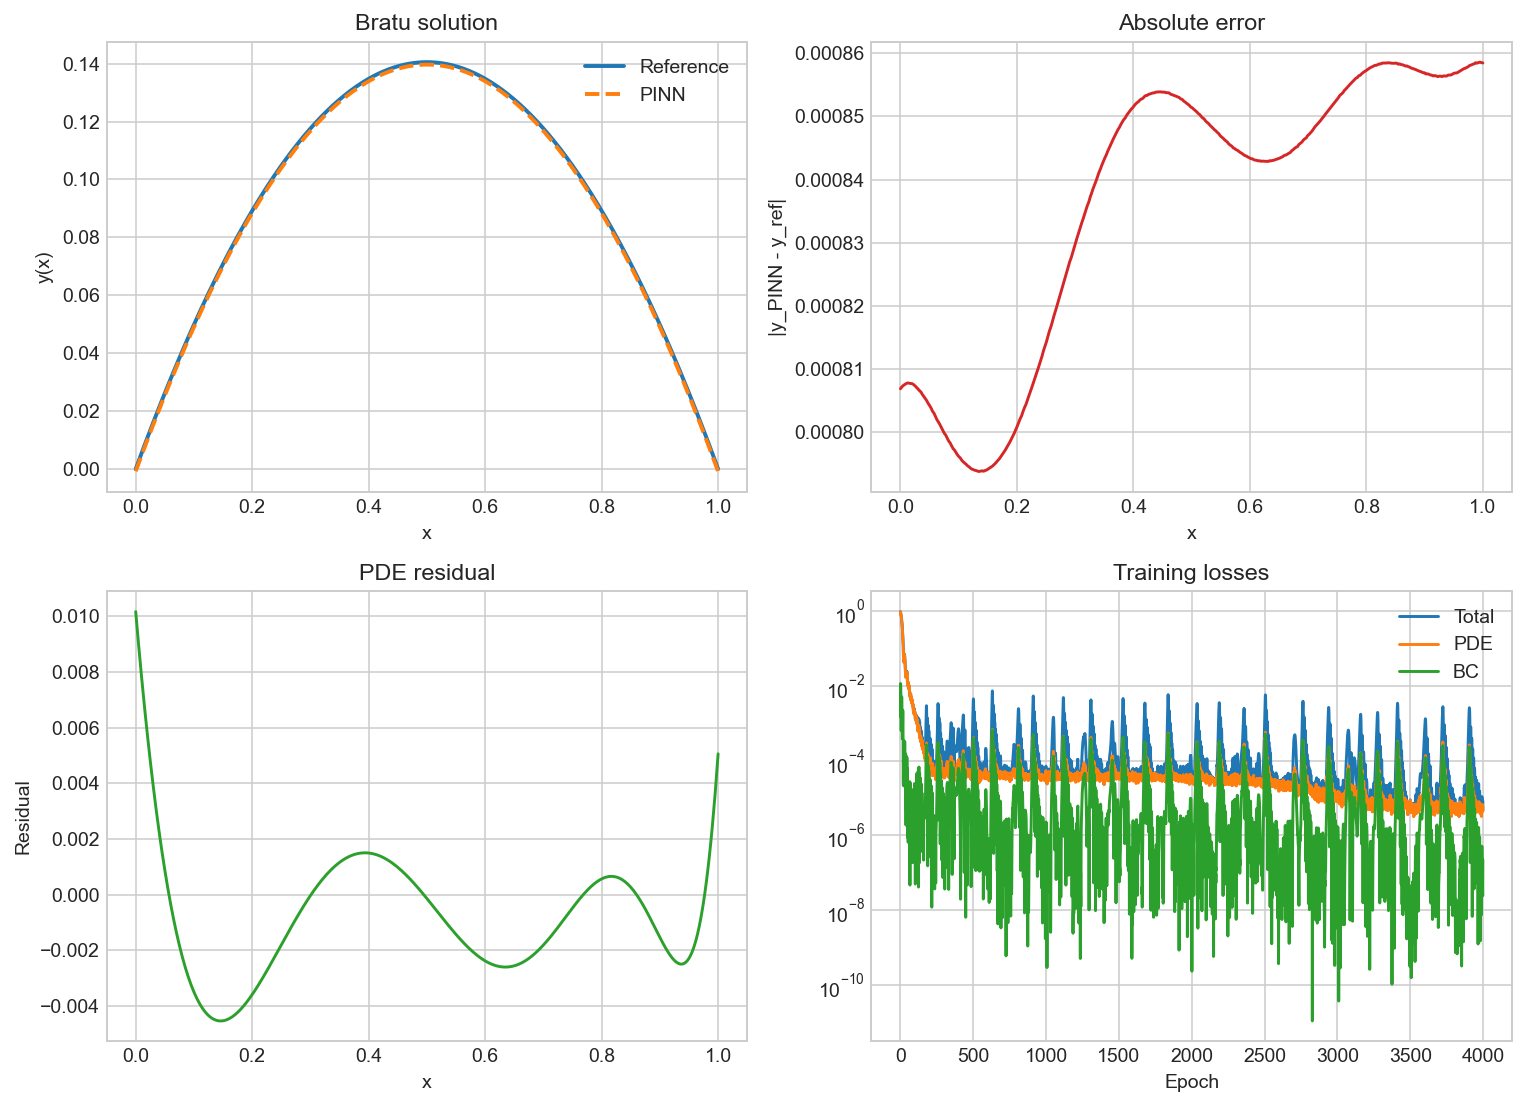

Max absolute error: 8.586e-04
Mean absolute error: 8.368e-04


In [17]:
x_plot = torch.linspace(0.0, 1.0, 400, device=device).reshape(-1, 1).requires_grad_(True)
y_pred_t, _, ddy_pred_t = bratu_derivatives(model, x_plot)
residual_plot = (ddy_pred_t + LAM * torch.exp(y_pred_t)).detach().cpu().numpy().reshape(-1)
y_pred = y_pred_t.detach().cpu().numpy().reshape(-1)
abs_error = np.abs(y_pred - y_ref)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(X_REF, y_ref, label="Reference", linewidth=2)
axes[0, 0].plot(X_REF, y_pred, "--", label="PINN", linewidth=2)
axes[0, 0].set_title("Bratu solution")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y(x)")
axes[0, 0].legend()

axes[0, 1].plot(X_REF, abs_error, color="tab:red")
axes[0, 1].set_title("Absolute error")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("|y_PINN - y_ref|")

axes[1, 0].plot(X_REF, residual_plot, color="tab:green")
axes[1, 0].set_title("PDE residual")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("Residual")

axes[1, 1].plot(history["total"], label="Total")
axes[1, 1].plot(history["pde"], label="PDE")
axes[1, 1].plot(history["bc"], label="BC")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Training losses")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()

savefig(fig, "bratu_summary.png")
plt.show()


print(f"Max absolute error: {abs_error.max():.3e}")
print(f"Mean absolute error: {abs_error.mean():.3e}")

## Key takeaway

The Bratu problem is a clean example of a nonlinear BVP that a standard PINN can solve well. The formulation is naturally stated in terms of a differential equation plus boundary conditions, so a PINN is the right abstraction; HJB/PMP would only be an artificial reformulation here.
